# What Makes a Red Wine *Good*? A Data-Driven Tasting

The **Vinho Verde** red wine dataset (Cortez et al., 2009) gives us something wonderful:the *chemistry* of 1,599 Portuguese red wines, paired with a **quality score** (0–10)assigned by human tasters.

There's no data on grape variety, brand or price — only what a lab can measure. So the question at the heart of this notebook is:

> **Can the physical chemistry of a wine predict whether an expert will call it good?**

We'll explore the data, hunt for the chemical signature of quality and then trainmodels to make the call. Along the way I'll explain *why* at each step, not just *what*.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

WINE   = "#7b1e2b"
BLUSH  = "#c76d7e"
GOLD   = "#c9a24b"
INK    = "#2b2b2b"

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "axes.edgecolor": "#cccccc",
})

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(
    "/kaggle/input/datasets/organizations/uciml/red-wine-quality-cortez-et-al-2009/winequality-red.csv"
)

print("Rows, columns:", df.shape)
df.head()

Rows, columns: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## First Look

Before touching a model, we interrogate the data. Three questions:

1. What *are* these columns and are any values missing?
2. Are there **duplicate rows**? (Yes and it matters)
3. What does our target, `quality`, actually look like?

In [3]:
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar      

In [4]:
dupes = df.duplicated().sum()

print(f"Duplicate rows: {dupes}  ({dupes/len(df):.1%} of the data)")
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(6)

Duplicate rows: 240  (15.0% of the data)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
142,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.9916,3.68,0.79,14.0,6
144,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.9916,3.68,0.79,14.0,6
131,5.6,0.50,0.09,2.3,0.049,17.0,99.0,0.9937,3.63,0.63,13.0,5
132,5.6,0.50,0.09,2.3,0.049,17.0,99.0,0.9937,3.63,0.63,13.0,5
1488,5.6,0.54,0.04,1.7,0.049,5.0,13.0,0.9942,3.72,0.58,11.4,5
1491,5.6,0.54,0.04,1.7,0.049,5.0,13.0,0.9942,3.72,0.58,11.4,5


## The Target: `quality`

Everything hinges on understanding what we're predicting. Let's look at howquality scores are distributed and brace ourselves, because it's lopsided.

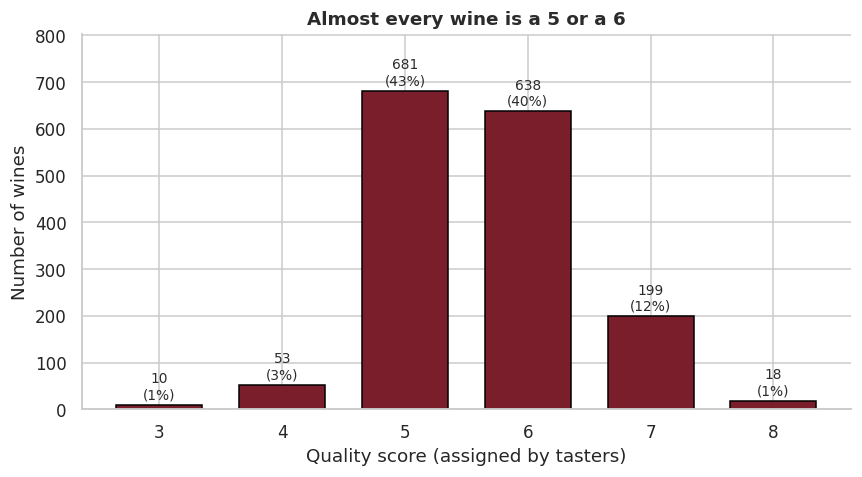

In [5]:
counts = df["quality"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(counts.index, counts.values, color=WINE, edgecolor="black", width=0.7)

for x, v in zip(counts.index, counts.values):
    ax.text(x, v + 6, f"{v}\n({v/len(df):.0%})",
            ha="center", va="bottom", fontsize=9, color=INK)

ax.set_title("Almost every wine is a 5 or a 6")
ax.set_xlabel("Quality score (assigned by tasters)")
ax.set_ylabel("Number of wines")
ax.set_ylim(0, counts.max() * 1.18)
sns.despine()
plt.tight_layout()
plt.show()

### Two facts that shape everything downstream

**Fact 1 — It's extremely imbalanced.** Roughly **83%** of wines are a 5 or 6.The best wines (8) and worst (3) are rarities, a handful of examples each. A lazy model could predict "6" for every wine and still be right much of the time.That means **accuracy will be a misleading score** and we'll need to lean on metricsthat respect the rare classes.

**Fact 2 — The target is *ordinal*, not just categorical.** A 7 is better than a 6,which is better than a 5 — the labels have an order. This gives us a choice of framing:

- **Regression** — predict the numeric score, honoring the order.
- **Multi-class** — predict which of 6 classes, but ignore the ordering and starve on the rare classes.
- **Binary** — collapse into *"good"* vs *"not good."* Simplest, most robust and answers a genuinely useful question.

We'll commit to the **binary framing** shortly but only after we've explored whatactually separates a good wine from a bad one.

## The Chemistry, One Feature at a Time (Univariate EDA)

Eleven measurements describe each wine. Before asking how they relate to *quality*, let's just look at each one's shape. We're hunting for skew (lopsided distributions)and outliers both influence which models and preprocessing make sense.

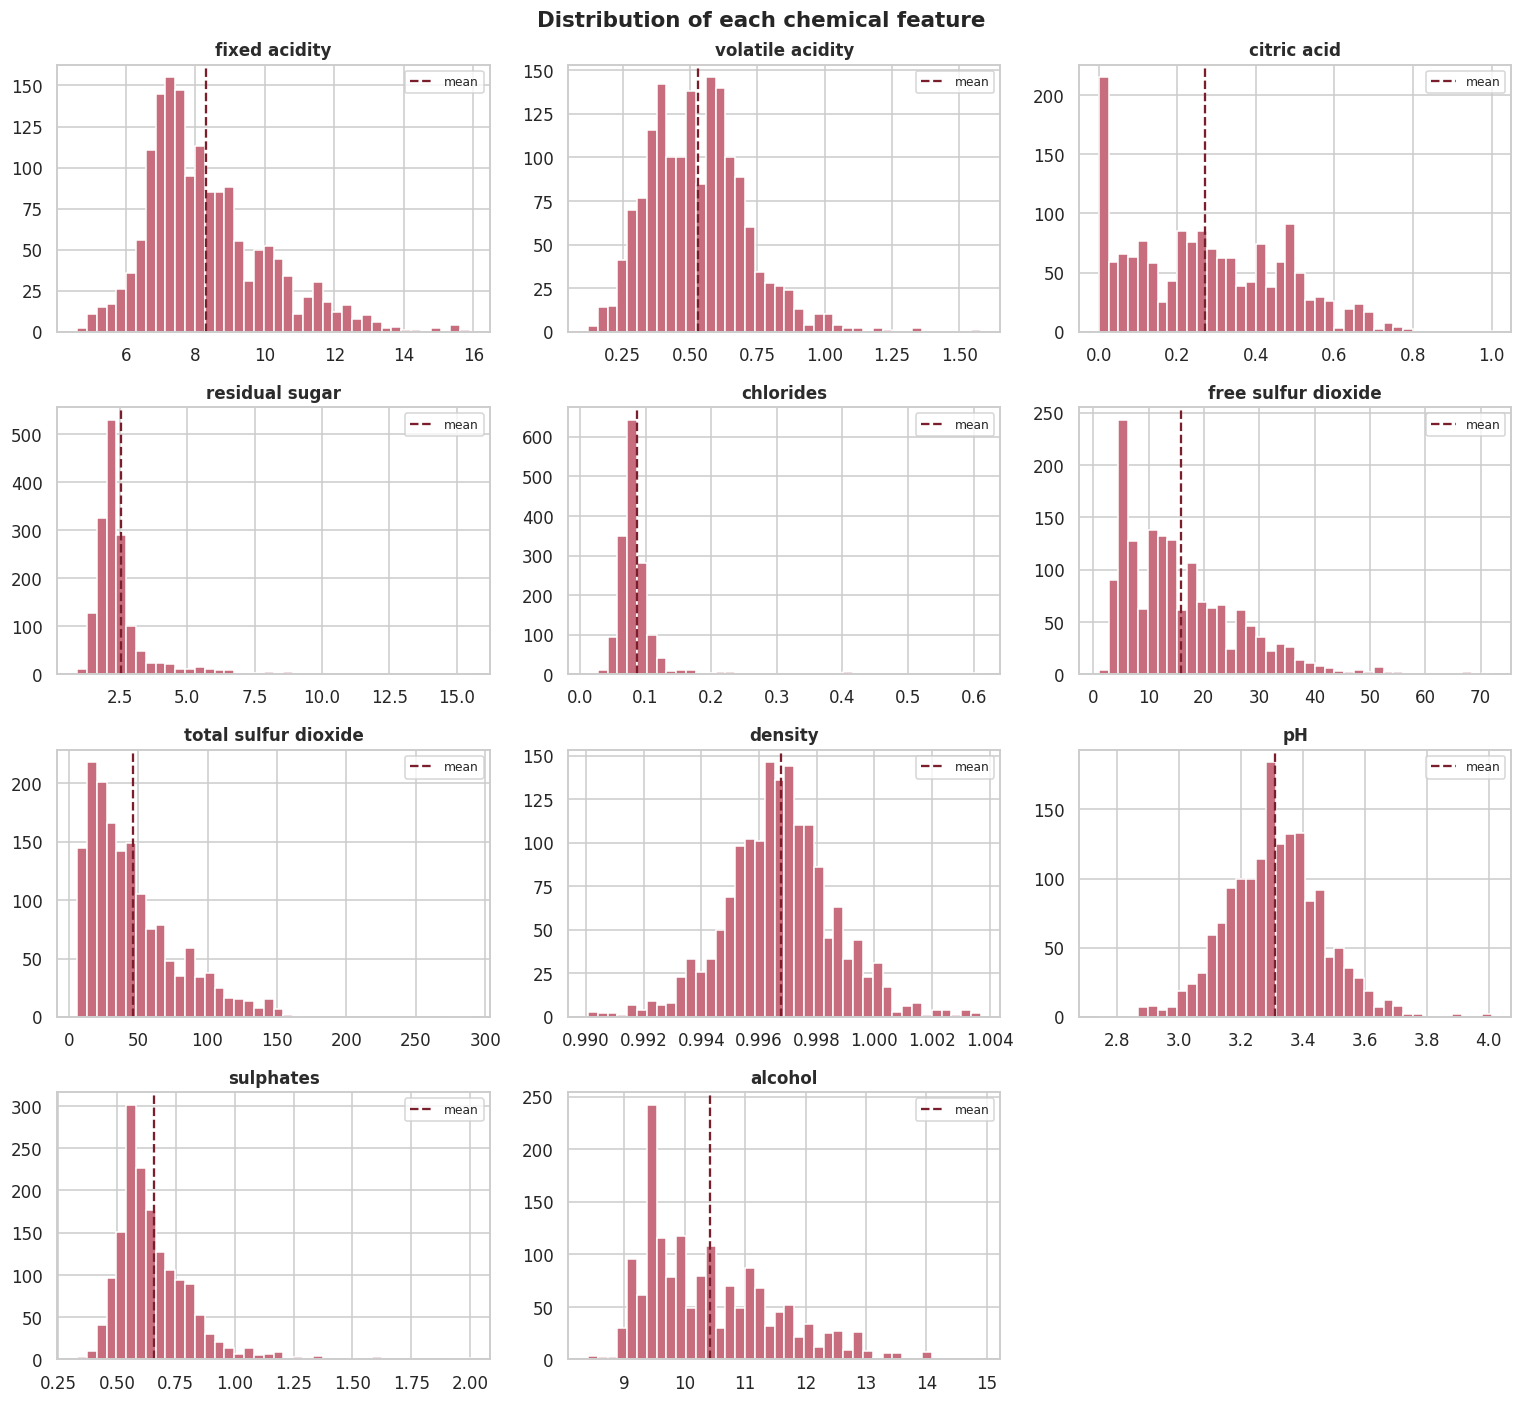

In [6]:
features = [c for c in df.columns if c != "quality"]

fig, axes = plt.subplots(4, 3, figsize=(14, 13))
axes = axes.ravel()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=40, color=BLUSH, edgecolor="white")
    axes[i].axvline(df[col].mean(), color=WINE, linestyle="--", linewidth=1.5,
                    label="mean")
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)

axes[-1].axis("off")

fig.suptitle("Distribution of each chemical feature", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Reading the shapes

A few patterns jump out:

- **Right-skewed with long tails:** `residual sugar`, `chlorides` and both sulfurdioxide features. Most wines cluster low, but a few stretch far to the right those long tails are outliers, not errors.
- **Roughly bell-shaped:** `density`, `pH`, and `fixed acidity` are fairly symmetric.
- **`alcohol`** spans about 8.4% to 14.9% and leans toward the lower end.

**Why we care:** skew and outliers hurt distance and coefficient-based models(like logistic regression) far more than tree-based models (like random forests),which only care about *rank order*, not scale. This is exactly why, later, we'll **scale the features for logistic regression but leave the trees alone** and whywe won't bother deleting outliers, since our strongest models are immune to them.

## What Actually Drives Quality? (Bivariate EDA)

Now the real question: which chemical properties move *with* quality? We'll start with a correlation heatmap for the full picture, then zoom in on the strongest relationships.

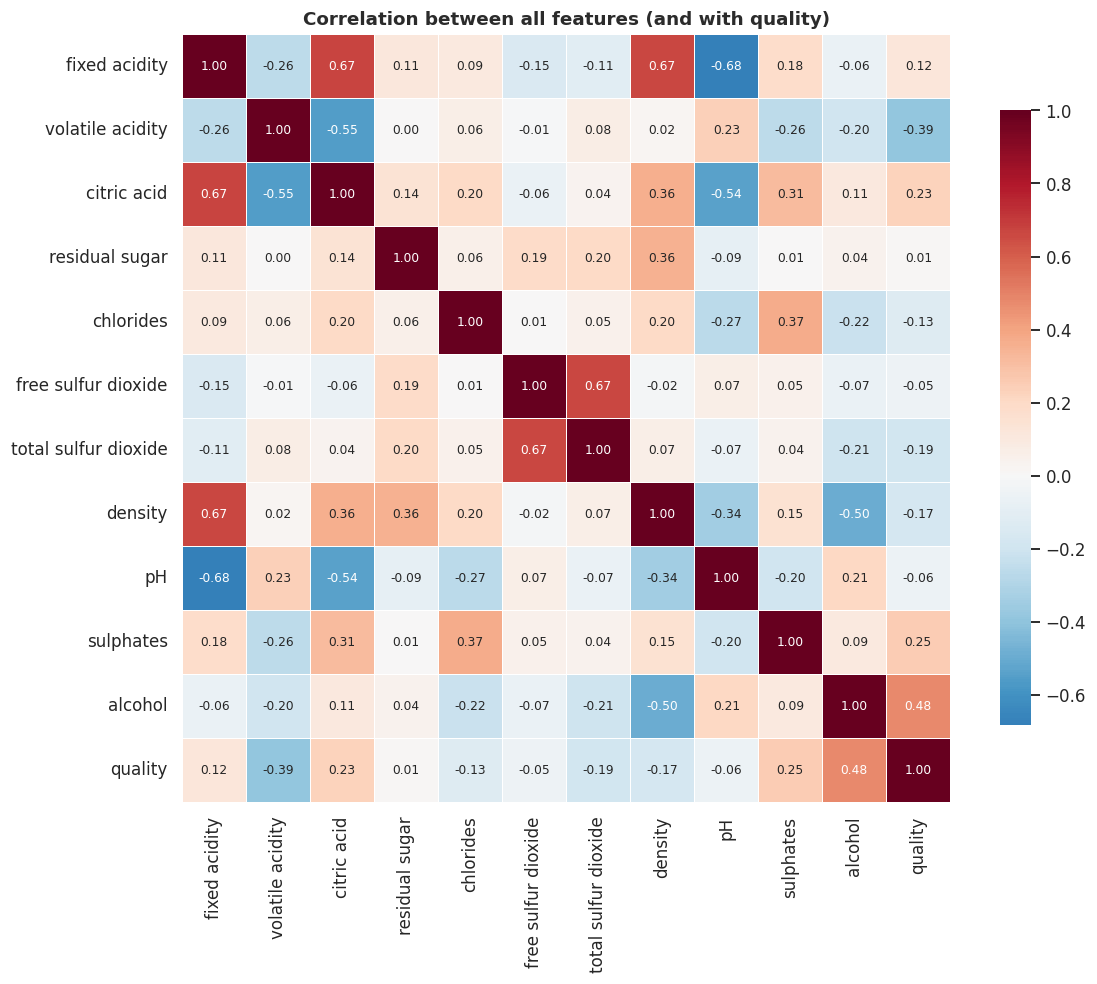

In [7]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}, ax=ax,
)

ax.set_title("Correlation between all features (and with quality)")
plt.tight_layout()
plt.show()

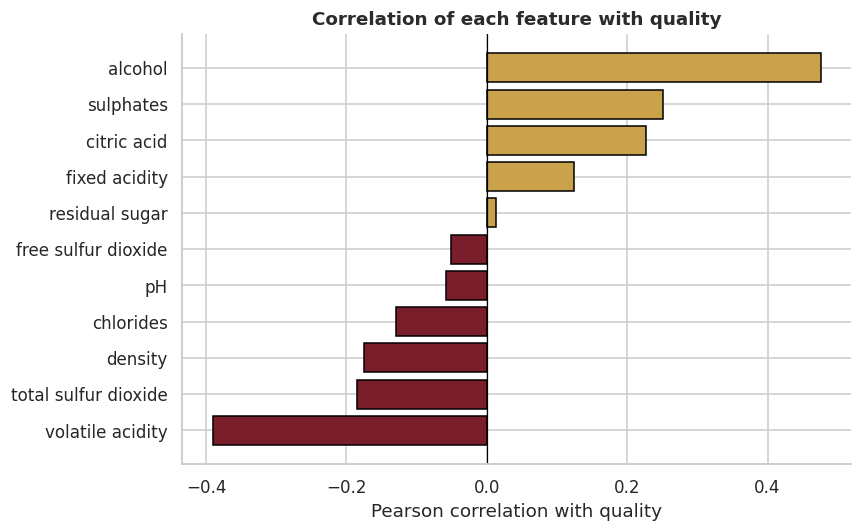

In [8]:
quality_corr = corr["quality"].drop("quality").sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = [WINE if v < 0 else GOLD for v in quality_corr.values]

ax.barh(quality_corr.index, quality_corr.values, color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation of each feature with quality")
ax.set_xlabel("Pearson correlation with quality")
sns.despine()
plt.tight_layout()
plt.show()

### The signal emerges

Ranked by correlation with quality, four features stand out:

| Feature | Corr. | Reading |
|---|---|---|
| **alcohol** | **+0.48** | The single strongest signal richer, more alcoholic wines score higher |
| **volatile acidity** | **−0.39** | The strongest *negative* it's the "vinegar" acid; more of it, worse the wine |
| **sulphates** | +0.25 | A preservative; modest positive link to quality |
| **citric acid** | +0.23 | Adds freshness; mild positive link |

Two honest caveats that a careful analyst always adds:

- **Correlation is linear and pairwise.** A feature with near-zero correlation(like `pH`) isn't necessarily useless it might matter *in combination* with others, which our models can capture even when a heatmap can't.
- **Correlation ≠ causation.** High alcohol doesn't *cause* a good rating; both may stem from riper grapes and better winemaking. We're finding predictive signal, not proving mechanism.

So the headline story is: **more alcohol, less volatile acidity.** Let's make that tangible with a visual you don't see every day.

## The Chemical Fingerprint of a Great Wine

Correlations tell us *which* features matter. But what does a great wine actually *look like* across all of them at once? Let's build a radar chart comparing the average profile of **top wines (quality ≥ 7)** against **poor wines (quality ≤ 4)**.

Since features live on wildly different scales (alcohol ~10 vs density ~0.99), we min–max normalize each to 0–1 first, so the *shape* reflects relative position, not raw magnitude.

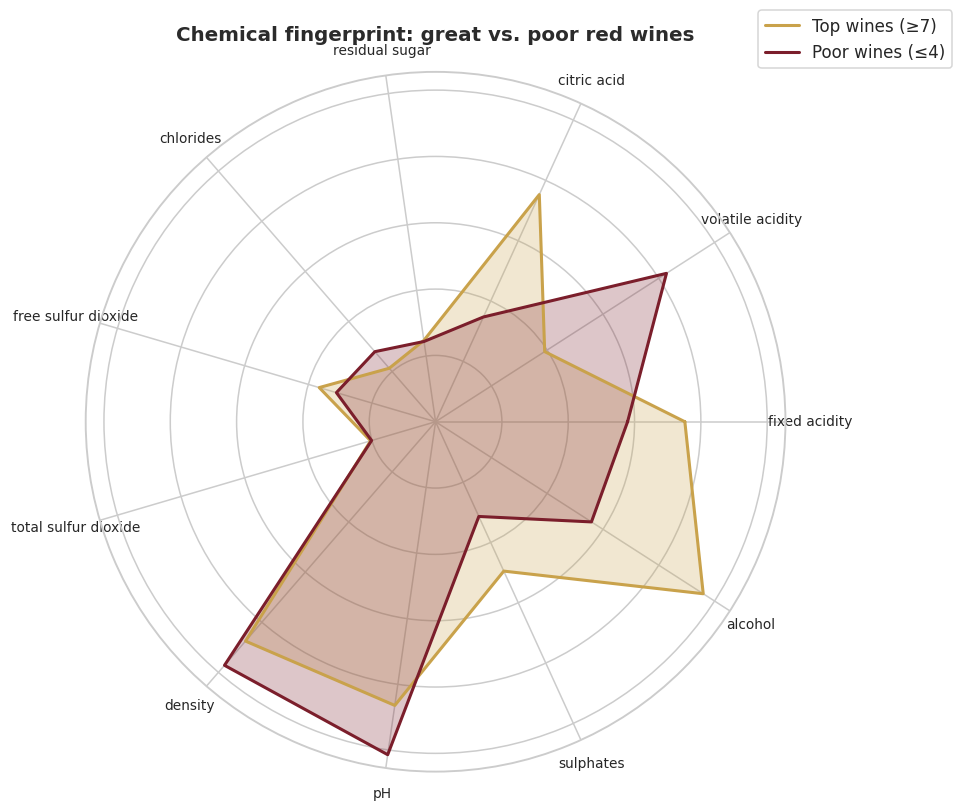

In [9]:
from math import pi

norm = (df[features] - df[features].min()) / (df[features].max() - df[features].min())
norm["quality"] = df["quality"]

top  = norm[norm["quality"] >= 7][features].mean().tolist()
poor = norm[norm["quality"] <= 4][features].mean().tolist()

angles = [n / len(features) * 2 * pi for n in range(len(features))]
angles += angles[:1]
top  += top[:1]
poor += poor[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for vals, color, label in [(top, GOLD, "Top wines (≥7)"),
                           (poor, WINE, "Poor wines (≤4)")]:
    ax.plot(angles, vals, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=9)
ax.set_yticklabels([])
ax.set_title("Chemical fingerprint: great vs. poor red wines\n", fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()

Read it like two overlapping constellations. Where **gold pushes outward past red**, that trait favors good wine you'll see it bulge on **alcohol, sulphates and citric acid**. Where **red pushes out past gold**, **volatile acidity** that's the signature of a poorer wine. It's the same story the correlations told, now as a single glance-able shape.

## Framing the ML Problem and Preprocessing

Time to model. Three deliberate decisions:

1. **Binary target** — we predict **good (quality ≥ 7)** vs **not good**. This gives a robust, useful classifier instead of starving on rare classes 3 and 8.
2. **Drop duplicates before splitting** so no identical row leaks across the train/test boundary and inflates our scores.
3. **Split first, scale second** we fit the scaler on *training data only*, then apply it to test. Fitting on all data would leak test information.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

model_df = df.drop_duplicates().reset_index(drop=True)
model_df["good"] = (model_df["quality"] >= 7).astype(int)

X = model_df[features]
y = model_df["good"]

print("Class balance (good=1):")
print(y.value_counts(normalize=True).round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Good-wine rate — train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

Class balance (good=1):
good
0    0.865
1    0.135
Name: proportion, dtype: float64

Train: 1087 rows | Test: 272 rows
Good-wine rate — train: 0.135, test: 0.136


## Modeling

We'll train four classifiers of increasing sophistication and compare them *fairly* using **5-fold stratified cross-validation** on the training set (so every fold keeps the 13.5% good-wine ratio). Two principles guide us:

- **Always start with a baseline.** If a fancy model can't beat "predict the majority class," it's worthless. The baseline is our zero line.
- **Handle the imbalance.** Each real model gets a class-weight setting so the rare "good" wines aren't ignored, otherwise the model just learns to always say "not good".

We score on **F1** (the balance of precision and recall on the rare class), not accuracy because with 86% "not good" accuracy rewards laziness.

In [11]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

spw = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Baseline (majority)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=300,
                                                  class_weight="balanced",
                                                  random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=400, max_depth=4,
                                         learning_rate=0.05, subsample=0.8,
                                         colsample_bytree=0.8, eval_metric="logloss",
                                         scale_pos_weight=spw, random_state=42),
}

needs_scaling = {"Logistic Regression"}
print(f"Imbalance ratio passed to XGBoost (scale_pos_weight): {spw:.2f}")

Imbalance ratio passed to XGBoost (scale_pos_weight): 6.39


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    Xt = X_train_s if name in needs_scaling else X_train.values
    scores = cross_val_score(model, Xt, y_train, cv=cv, scoring="f1")
    cv_results[name] = scores
    print(f"{name:22s}  F1 = {scores.mean():.3f}  ± {scores.std():.3f}")

Baseline (majority)     F1 = 0.000  ± 0.000
Logistic Regression     F1 = 0.508  ± 0.017
Random Forest           F1 = 0.399  ± 0.061
XGBoost                 F1 = 0.488  ± 0.084


## Honest Evaluation on the Test Set

Cross-validation picked our contenders; now we judge them on the **untouched test set**. We look beyond a single number:

- **Confusion matrix** where exactly does the model succeed and fail?
- **Precision / recall / F1** precision = "when it says *good* is it right?"; recall = "of the truly good wines, how many did it catch?"
- **ROC-AUC** ranking quality across *all* thresholds, a threshold-free score.

In [13]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)

fitted, test_scores = {}, {}

for name, model in models.items():
    Xtr = X_train_s if name in needs_scaling else X_train.values
    Xte = X_test_s  if name in needs_scaling else X_test.values
    
    model.fit(Xtr, y_train)
    fitted[name] = model
    pred = model.predict(Xte)
    
    try:
        proba = model.predict_proba(Xte)[:, 1]
        auc = roc_auc_score(y_test, proba)
        
    except Exception:
        auc = float("nan")
        
    test_scores[name] = {"F1": f1_score(y_test, pred), "ROC-AUC": auc}

pd.DataFrame(test_scores).T.round(3).sort_values("ROC-AUC", ascending=False)

,F1,ROC-AUC
Logistic Regression,0.513,0.885
XGBoost,0.541,0.884
Random Forest,0.473,0.883
Baseline (majority),0.000,0.500


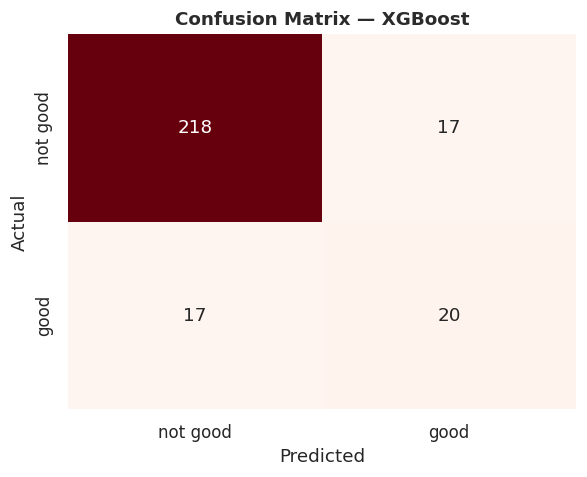

Classification report — XGBoost

              precision    recall  f1-score   support

    not good       0.93      0.93      0.93       235
        good       0.54      0.54      0.54        37

    accuracy                           0.88       272
   macro avg       0.73      0.73      0.73       272
weighted avg       0.88      0.88      0.88       272



In [14]:
best_name = "XGBoost"
best = fitted[best_name]
Xte = X_test_s if best_name in needs_scaling else X_test.values
pred = best.predict(Xte)

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False,
            xticklabels=["not good", "good"],
            yticklabels=["not good", "good"], ax=ax)

ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

print(f"Classification report — {best_name}\n")
print(classification_report(y_test, pred, target_names=["not good", "good"]))

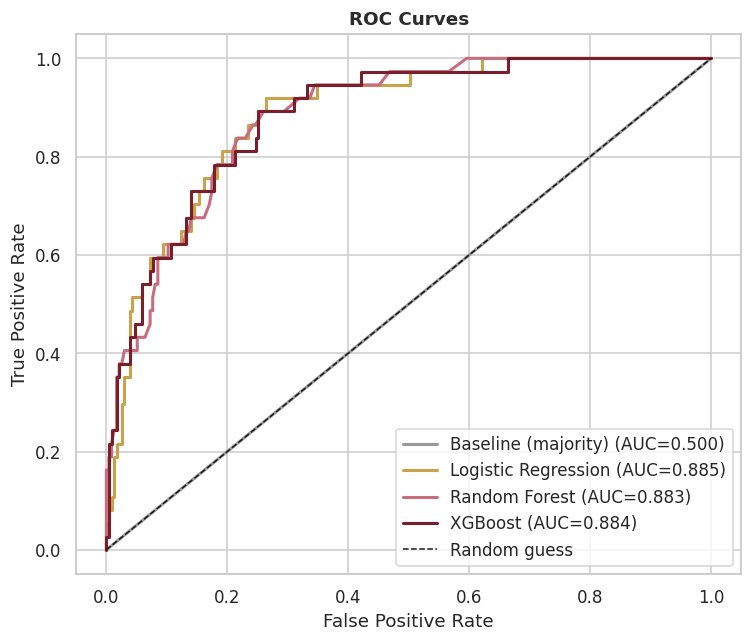

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
palette = {"Baseline (majority)": "#999999", "Logistic Regression": GOLD,
           "Random Forest": BLUSH, "XGBoost": WINE}

for name, model in fitted.items():
    Xte = X_test_s if name in needs_scaling else X_test.values
    
    try:
        proba = model.predict_proba(Xte)[:, 1]
    except Exception:
        continue
        
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    
    ax.plot(fpr, tpr, color=palette[name], linewidth=2,
            label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random guess")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves"); ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## What Did the Model Learn? (Feature Importance)

A model is more trustworthy when its reasoning matches domain sense. We check two ways:

- **Built-in importance** how often/effectively XGBoost split on each feature.
- **Permutation importance** shuffle one feature and watch how much test performance drops. This is model-agnostic and often more honest, since it measures impact on *held-out* predictions rather than training structure.

If these line up with our EDA (alcohol up, volatile acidity down) the story is coherent.

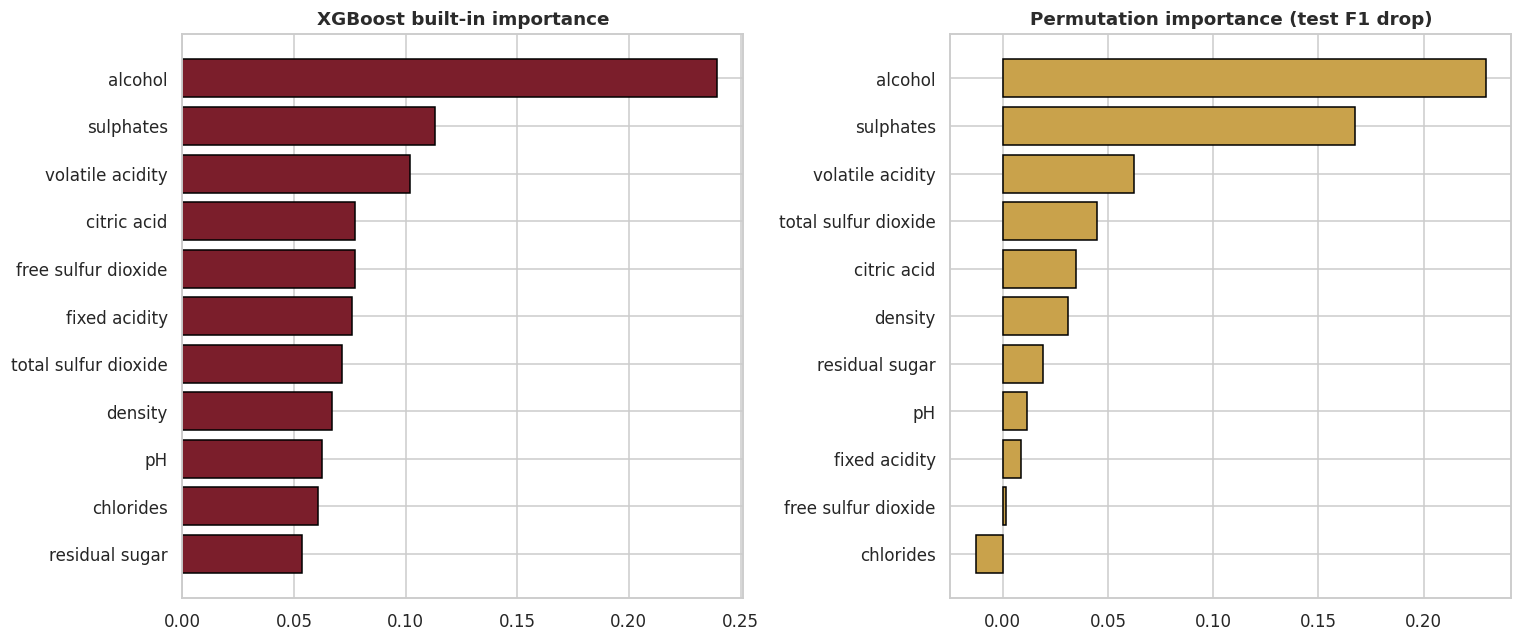

In [16]:
from sklearn.inspection import permutation_importance

xgb = fitted["XGBoost"]

builtin = pd.Series(xgb.feature_importances_, index=features).sort_values()

perm = permutation_importance(xgb, X_test.values, y_test,
                              n_repeats=20, random_state=42, scoring="f1")
perm_imp = pd.Series(perm.importances_mean, index=features).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(builtin.index, builtin.values, color=WINE, edgecolor="black")
axes[0].set_title("XGBoost built-in importance")

axes[1].barh(perm_imp.index, perm_imp.values, color=GOLD, edgecolor="black")
axes[1].set_title("Permutation importance (test F1 drop)")

plt.tight_layout()
plt.show()

### The story holds together

**alcohol**, **sulphates**, and **volatile acidity** rise to the top, the same trio our correlations and radar chart flagged. When a model trained blind lands on the same drivers a human analyst spotted, that's a strong sign we've found real signal rather than noise. The model didn't just memorize it learned the chemistry that experts implicitly taste.

## Peering Inside the Model with SHAP

Feature importance told us *which* features matter overall. **SHAP** (SHapley Additive exPlanations) goes deeper: it assigns every feature a signed contribution *for every individual wine* grounded in game theory. It answers two questions our bar charts couldn't:

- **Globally:** does high alcohol push wines toward "good" or is the relationship messier?
- **Locally:** for *this specific wine*, why did the model decide as it did?

Because XGBoost is tree-based, SHAP computes these exactly and fast via `TreeExplainer`.

In [17]:
import shap

xgb = fitted["XGBoost"]

explainer = shap.TreeExplainer(xgb)

X_test_df = pd.DataFrame(X_test.values, columns=features)
shap_values = explainer.shap_values(X_test_df)

print("SHAP values shape:", np.array(shap_values).shape)
print("(rows = test wines, columns = features)")

SHAP values shape: (272, 11)
(rows = test wines, columns = features)


### The Global View — SHAP Beeswarm

This is the plot to study. Each dot is one wine. Position left/right shows whether that feature pushed the prediction toward **not good** (left) or **good** (right). Colour shows the feature's value (red = high, blue = low). Features are ranked by overall impact, top = most influential.

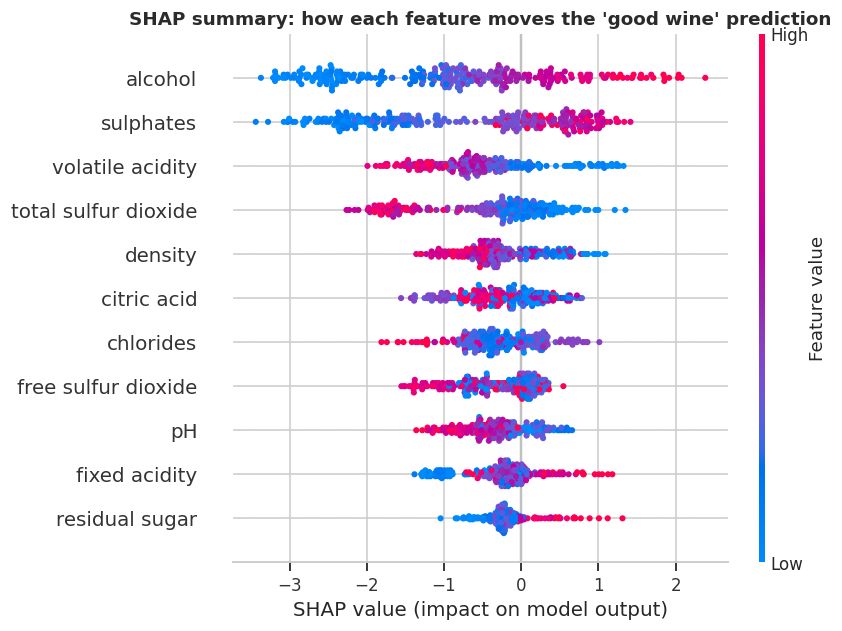

In [18]:
shap.summary_plot(shap_values, X_test_df, show=False)

plt.title("SHAP summary: how each feature moves the 'good wine' prediction",
          fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

### Reading the beeswarm

The story sharpens beautifully:

- **alcohol** sits at (or near) the top. Its **red dots (high alcohol) sit on the right** high alcohol consistently pushes a wine toward *good*. Exactly what our correlation and radar chart predicted, now confirmed at the level of individual wines.
- **volatile acidity** shows the mirror image: **red (high) dots on the left** more of that vinegary acid drags predictions toward *not good*.
- **sulphates** leans the same helpful direction as alcohol.

SHAP doesn't just rank features it reveals the *direction and consistency* of each effect. This is the difference between "alcohol is important" and "high alcohol reliably makes the model believe a wine is good."

### The Local View — Explaining One Wine

SHAP's real magic is per-prediction. Let's take one wine the model is confident about and break down *exactly* which features drove that call.

Explaining test wine #226 — model says P(good) = 0.99
Actual label: good


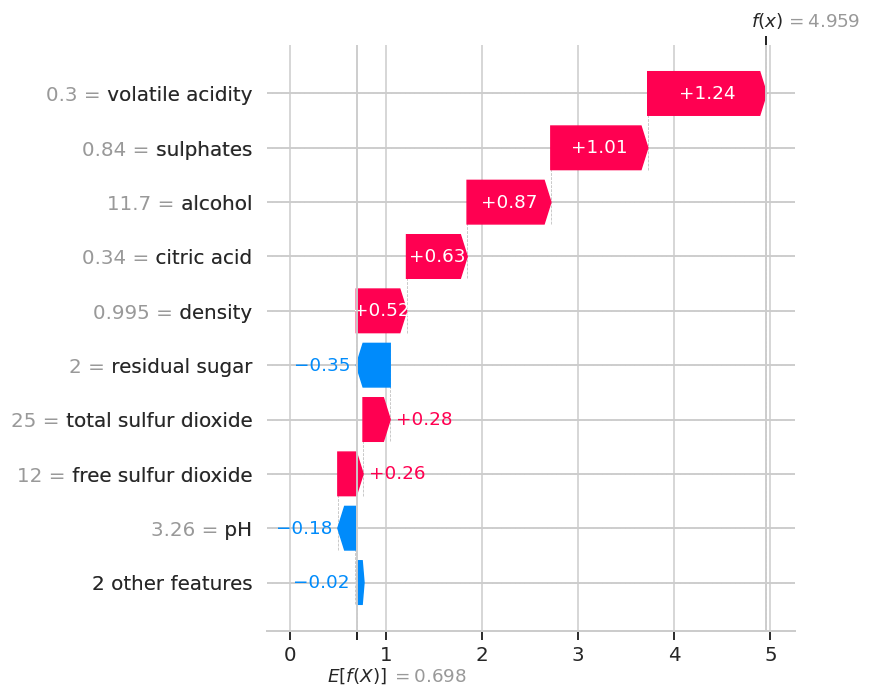

In [19]:
proba = xgb.predict_proba(X_test_df.values)[:, 1]
i = int(np.argmax(proba))

print(f"Explaining test wine #{i} — model says P(good) = {proba[i]:.2f}")
print(f"Actual label: {'good' if y_test.iloc[i] == 1 else 'not good'}")

try:
    expl = shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[i],
        feature_names=features,
    )
    shap.plots.waterfall(expl, show=False)
except Exception:
    shap.bar_plot(shap_values[i], feature_names=features, max_display=11)

plt.tight_layout()
plt.show()

### Reading this wine

This is the wine the model is *most confident* is good. Starting from a baseline of **E[f(X)] = 0.70**, features stack up to a final score of **f(x) ≈ 4.96** a strong "good" vote. The three biggest pushes are our familiar headliners:

- **volatile acidity = 0.3** (+1.24): this is a *low* value, and low volatile acidity is precisely what signals quality so it's the single strongest push toward "good."
- **sulphates = 0.84** (+1.01) and **alcohol = 11.7** (+0.87): both elevated, both pushing up, exactly as our EDA predicted.

A subtlety worth flagging: the colours encode each feature's *contribution direction*, not simply "high/low." A low volatile acidity showing as a strong positive isn't a contradiction it's SHAP confirming that the *absence* of that vinegary acid is a core reason this wine scores well. Global patterns and this single prediction tell one coherent story.

## Error Analysis: Where — and Why — Does the Model Fail?

A score tells you *how often* the model is wrong. Error analysis tells you *how* it's wrong, which is far more useful. We'll ask three questions of the test set:

1. **What kind of errors** does the model make, does it miss good wines (false negatives) or cry wolf on bad ones (false positives)?
2. **Are the mistakes borderline or egregious?** A missed wine that scored exactly 7 is a near-miss; a missed 8 would be alarming.
3. **Do the errors cluster near the decision boundary**, where uncertainty is expected?

In [20]:
xgb = fitted["XGBoost"]
proba = xgb.predict_proba(X_test.values)[:, 1]
pred  = (proba >= 0.5).astype(int)

analysis = X_test.copy()
analysis["actual_quality"] = model_df.loc[X_test.index, "quality"].values
analysis["actual_good"]    = y_test.values
analysis["pred_good"]      = pred
analysis["prob_good"]      = proba

assert (analysis.loc[analysis.actual_good == 1, "actual_quality"] >= 7).all(), \
    "quality/label mismatch — indices are misaligned"

def kind(r):
    if r.actual_good == r.pred_good:
        return "correct"
    return "false negative" if r.actual_good == 1 else "false positive"

analysis["result"] = analysis.apply(kind, axis=1)
print(analysis["result"].value_counts())

result
correct           238
false positive     17
false negative     17
Name: count, dtype: int64


### Are the misses borderline?

If our false negatives were mostly wines scoring exactly **7** (the lowest "good" score), that's reassuring the model is failing on genuinely ambiguous cases, not missing obviously-excellent wines. Let's check the original quality scores of the wines we got wrong.

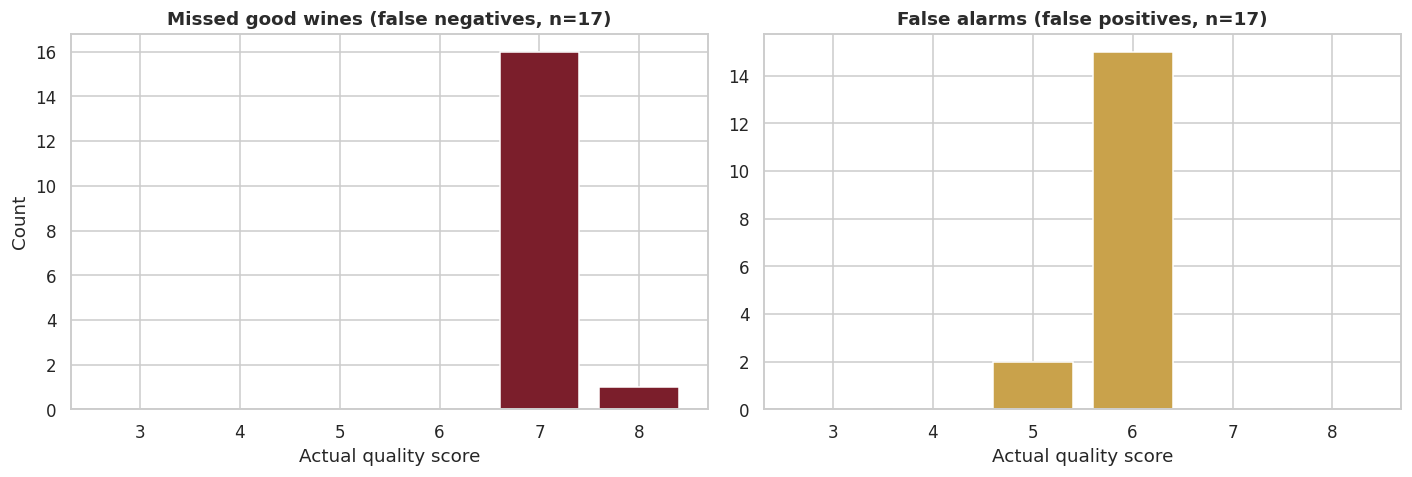

False negatives by quality:
 actual_quality
7    16
8     1
Name: count, dtype: int64

False positives by quality:
 actual_quality
5     2
6    15
Name: count, dtype: int64


In [21]:
fn = analysis[analysis["result"] == "false negative"]
fp = analysis[analysis["result"] == "false positive"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(fn["actual_quality"], bins=range(3, 10), color=WINE,
             edgecolor="white", align="left", rwidth=0.8)
axes[0].set_title(f"Missed good wines (false negatives, n={len(fn)})")
axes[0].set_xlabel("Actual quality score"); axes[0].set_ylabel("Count")

axes[1].hist(fp["actual_quality"], bins=range(3, 10), color=GOLD,
             edgecolor="white", align="left", rwidth=0.8)
axes[1].set_title(f"False alarms (false positives, n={len(fp)})")
axes[1].set_xlabel("Actual quality score")

plt.tight_layout()
plt.show()

print("False negatives by quality:\n", fn["actual_quality"].value_counts().sort_index())
print("\nFalse positives by quality:\n", fp["actual_quality"].value_counts().sort_index())

### Do errors cluster near the boundary?

A well-calibrated model should make most of its mistakes when its confidence is near 0.5 the fence it's sitting on. If errors were happening at high confidence, that would signal something broken. Let's plot predicted probability against the truth.

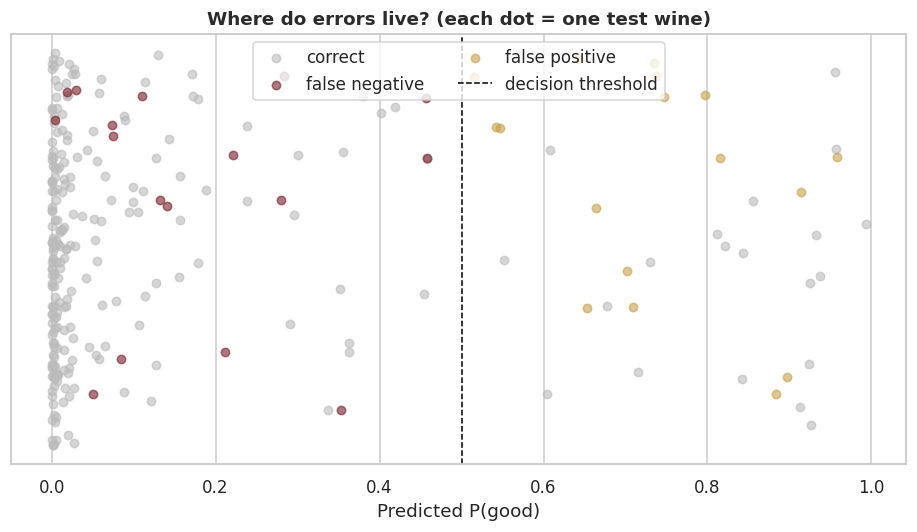

In [22]:
fig, ax = plt.subplots(figsize=(8.5, 5))

for result, color in [("correct", "#bbbbbb"),
                      ("false negative", WINE),
                      ("false positive", GOLD)]:
    subset = analysis[analysis["result"] == result]
    ax.scatter(subset["prob_good"],
               np.random.uniform(-0.4, 0.4, len(subset)),
               alpha=0.6, s=30, color=color, label=result)

ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="decision threshold")
ax.set_yticks([])
ax.set_xlabel("Predicted P(good)")
ax.set_title("Where do errors live? (each dot = one test wine)")
ax.legend(loc="upper center", ncol=2)
plt.tight_layout()
plt.show()

### What the errors tell us

The mistakes aren't random or alarming — they're almost entirely at the **6/7 boundary**, exactly where "good" and "not good" genuinely blur:

- **16 of 17 missed good wines scored 7** the lowest "good" grade. Only one quality-8 wine slipped past. The model isn't botching excellent wines; it hesitates on borderline 7s.
- **15 of 17 false alarms scored 6** the highest "not good" grade, right below the cutoff.

This reframes our ~0.54 recall honestly: much of the "failure" is the model being appropriately uncertain about inherently ambiguous wines the same near-ties a human taster would waver on, not a flaw in its grasp of wine chemistry.

## Conclusions

We set out with one question: **can a wine's chemistry alone predict whether an expert calls it good?** After taking the data from raw measurements all the way to explaining individual predictions, the answer is a confident and *interpretable*, *yes, mostly.*

**What we found**
- Red wines are separable by chemistry alone: our models reach **ROC-AUC ≈ 0.89**.
- Every lens we used, correlation, the radar fingerprint, feature importance and SHAP, told the *same* story: **more alcohol, more sulphates, lower volatile acidity.** When four independent methods agree, we can trust the signal is real.
- Catching the rare "good" wines is genuinely hard (**recall ≈ 0.54**), a direct consequence of only 13.5% of wines qualifying as good.
- A humble **Logistic Regression kept pace with XGBoost** on small, largely linear data, sophistication isn't automatically better.
- **SHAP** took us past *which* features matter to *how* and *why*, right down to explaining a single bottle's prediction.
- **Error analysis** revealed the mistakes cluster almost entirely at the **6/7 boundary** the model fails on genuinely ambiguous wines, not clear-cut ones. Its ~0.54 recall is less "the model is weak" and more "these wines are honestly borderline."

**Things we did carefully (and would do again)**
- Dropped 240 duplicate rows *before* splitting, to prevent train/test leakage.
- Fit the scaler on training data only, for the same reason.
- Judged models on F1 and ROC-AUC, not accuracy which would have rewarded a lazy "always predict not-good" model with a misleading 86%.
- Added a sanity-check `assert` that caught a real index-misalignment bug in our error analysis a reminder that quiet data bugs are the dangerous ones.

**Honest limitations**
- The minority "good" class is data-starved, capping how well any model can do.
- "Quality" is a subjective human average, a noisy target by nature.
- Findings describe *Portuguese Vinho Verde reds* specifically; don't over-generalize to all wine.

**Where I'd go next**
- Tune the decision threshold to trade precision for recall depending on the use-case.
- Revisit the full 3–8 scale as an **ordinal regression** problem.
- Gather or synthesize more good-wine examples to ease the imbalance.

**The throughline:** a model is only as trustworthy as it is *interpretable* and here the machine independently rediscovered what the chemistry told us from the very first correlation. That agreement, confirmed all the way down to individual predictions, is what turns a black box into an explanation.

*Thanks for reading! If this helped or taught you something, an upvote is much appreciated lads!*